In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt

from src.curves.interpolation import CurveInterpolator

from src.risk.IRRBB_shocks import IRRBBShock

In [ ]:
# synthetic yield curve data for testing
tenors = [0.25, 0.5, 1, 2, 5, 10, 20, 30]
rates = [0.03, 0.031, 0.033, 0.036, 0.039, 0.041, 0.043, 0.044]

interpolator = CurveInterpolator(
    tenors = tenors,
    rates = rates
)

base_curve = interpolator.build_interp_curve(
    max_years = 30,
    method = 'log_df'  
)

base_curve.rename(
    columns = {
        'tenor_years': 'tenor',
        'zero_rate': 'rate'
    },
    inplace = True
)

base_curve

,tenor,rate
0,0.002740,0.030000
1,0.005479,0.030000
2,0.008219,0.030000
3,0.010959,0.030000
4,0.013699,0.030000
...,...,...
10945,29.989041,0.043999
10946,29.991781,0.043999
10947,29.994521,0.044000
10948,29.997260,0.044000


In [3]:
# initiate shock engine
shock_engine = IRRBBShock(base_curve = base_curve)

# IRRBB shock scenarios
parallel_up = shock_engine.parallel_up()
parallel_down = shock_engine.parallel_down()
short_up = shock_engine.short_rate_up()
short_down = shock_engine.short_rate_down()
steepener = shock_engine.steepener()
flattener = shock_engine.flattener()

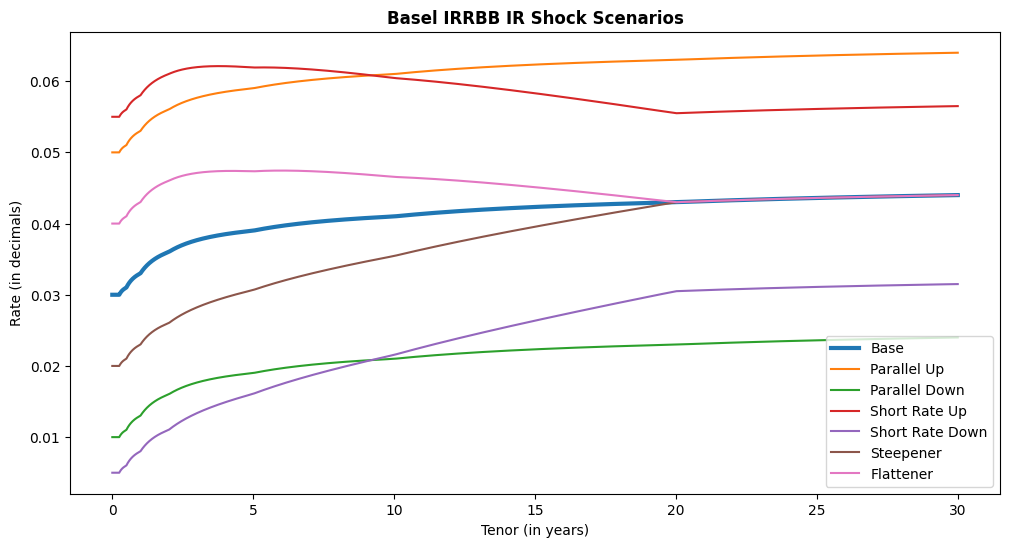

In [4]:
# plotting shocked curves
plt.figure(figsize=(12, 6))

plt.plot(base_curve.tenor, base_curve.rate, label = 'Base', linewidth = 3)
plt.plot(parallel_up.tenor, parallel_up.rate, label = 'Parallel Up')
plt.plot(parallel_down.tenor, parallel_down.rate, label = 'Parallel Down')
plt.plot(short_up.tenor, short_up.rate, label = 'Short Rate Up')
plt.plot(short_down.tenor, short_down.rate, label = 'Short Rate Down')
plt.plot(steepener.tenor, steepener.rate, label = 'Steepener')
plt.plot(flattener.tenor, flattener.rate, label = 'Flattener')

plt.legend()
plt.title("Basel IRRBB IR Shock Scenarios", fontweight = 'bold')
plt.xlabel('Tenor (in years)')
plt.ylabel('Rate (in decimals)')
plt.show()